In [1]:
import os
import sys
import time
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# 路径设置（假设在 tagging/unsmear 目录运行）
THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR
TAGGING_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..'))

sys.path.insert(0, MODULE_DIR)

import tool  # noqa: E402
from model import TokenUNet1D, CondFlowMatcher  # noqa: E402

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

RUN_NAME = 'unsmear_test_full1'
OUT_DIR = os.path.join(MODULE_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')

tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(TAGGING_DIR, 'test.h5'),
    'n_jets': 100000,
    'max_particles': 100,
    # unsmear 训练特征：'3d'/'4d'/'7d'
    'feature_kind': '7d',
    # 下游 tagger 评估特征（通常希望统一为 7d）
    'downstream_feature_kind': '7d',
    # consistency loss（目前只做 dR 一致性；其余可后续扩展）
    'consistency': {
        'w_dr': 0.2,
    },
    # heteroscedastic regression（对指定维度启用不确定性）
    'uncertainty': {
        'enabled': False,
        'on_features': ['log_E', 'log_pt_rel', 'log_E_rel'],
        'log_var_clip': 6.0,
    },
    'hlt_effects': {
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 1.5,
        'merge_enabled': True,
        'merge_radius': 0.01,
        # smear
        'pt_resolution': 0.10,
        'eta_resolution': 0.03,
        'phi_resolution': 0.03,
        # effloss（可先设为 0，避免不可逆缺失干扰）
        'efficiency_loss': 0.01,
    },
    'unet': {
        # input_dim 会在下方根据 feature_kind 自动覆盖
        'input_dim': 7,
        'base_channels': 64,
        'depth': 3,
        'dropout': 0.1,
        'return_reco': True,
        'predict_logvar': False,
        'add_mask_channel': True,
    },
    'fm': {
        # input_dim 会在下方根据 feature_kind 自动覆盖
        'input_dim': 7,
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers': 4,
        'ff_dim': 512,
        'dropout': 0.1,
        # time embedding（建议 max_freq 与 steps 匹配；默认 200 更稳）
        'time_n_freqs': 16,
        'time_max_freq': 200.0,
        'time_t_eps': 1e-4,
        # inference sampler: 'euler' or 'heun'
        'sampler': 'heun',
        'sample_steps': 20,
    },
    'training': {
        'batch_size': 256,
        'epochs': 40,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 3,
        'patience': 6,
    },
}

# 自动对齐维度
feat_names = tool.get_feat_names(CONFIG['feature_kind'])
D = len(feat_names)
CONFIG['unet']['input_dim'] = D
CONFIG['fm']['input_dim'] = D
CONFIG['unet']['predict_logvar'] = bool(CONFIG['uncertainty']['enabled'])

print('Data path:', CONFIG['data_path'])
print('Run dir:', OUT_DIR)
print('Feature kind:', CONFIG['feature_kind'], 'input_dim:', D, 'feat_names:', feat_names)

Device: cuda
Data path: d:\PracticeTagging\tagging\test.h5
Run dir: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1
Feature kind: 7d input_dim: 7 feat_names: ['dEta', 'dPhi', 'log_pt', 'log_E', 'log_pt_rel', 'log_E_rel', 'dR']


In [2]:
# Load raw constituents
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)  # [N,S,4]
mask_raw = pt > 0

print('Raw:', constituents_raw.shape, 'mask:', mask_raw.shape)
print('Signal:', int(labels.sum()), 'Bkg:', int((1 - labels).sum()))


Raw: (100000, 100, 4) mask: (100000, 100)
Signal: 49936 Bkg: 50064


In [3]:
# Build supervision pairs: target=pre-smear (after merge), input=post-smear
hcfg = tool.HLTEffectsCfg(**CONFIG['hlt_effects'])

pre_const, post_const, post_mask, origin_counts = tool.apply_hlt_effects_pair(
    constituents_raw,
    mask_raw,
    hcfg,
    seed=seed,
)

# 确保 pre/post 使用同一个 effloss 后 mask（非常关键：PRE-SMEAR 不能包含已被 effloss 丢弃的 token）
pre_const = pre_const.copy()
post_const = post_const.copy()
pre_const[~post_mask] = 0.0
post_const[~post_mask] = 0.0
assert np.all(pre_const[~post_mask] == 0.0) and np.all(post_const[~post_mask] == 0.0)

print('Pre/post:', pre_const.shape, post_const.shape, 'mask:', post_mask.shape)
print('Avg tokens per jet (post):', float(post_mask.sum(axis=1).mean()))
print('Merged-token fraction (post):', float((origin_counts[post_mask] > 1).mean()) if post_mask.any() else 0.0)

# Compute engineered features using post-smear axis for both sides
axis_post = tool.compute_jet_axis(post_const, post_mask)
feat_pre = tool.compute_features_with_axis(pre_const, post_mask, axis_post, kind=CONFIG['feature_kind'])
feat_post = tool.compute_features_with_axis(post_const, post_mask, axis_post, kind=CONFIG['feature_kind'])

print('Features:', feat_pre.shape, feat_post.shape, 'kind:', CONFIG['feature_kind'])

# split (jet-level)
idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=seed, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=seed, stratify=labels[temp_idx])
print(f"Split: train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,}")


Pre/post: (100000, 100, 4) (100000, 100, 4) mask: (100000, 100)
Avg tokens per jet (post): 32.45919
Merged-token fraction (post): 0.4786715256911833
Features: (100000, 100, 7) (100000, 100, 7) kind: 7d
Split: train=70,000 val=15,000 test=15,000


In [4]:
# Standardize using PRE-smear TRAIN statistics
feat_means, feat_stds = tool.get_stats(feat_pre, post_mask, train_idx)

x_train = tool.standardize(feat_post, post_mask, feat_means, feat_stds, clip=10.0)
y_train = tool.standardize(feat_pre, post_mask, feat_means, feat_stds, clip=10.0)

print('Standardization done.')
print('Means:', np.round(feat_means, 4))
print('Stds :', np.round(feat_stds, 4))


Standardization done.
Means: [ 1.0000e-04  1.0000e-04  9.0410e+00  9.3461e+00 -4.9262e+00 -4.9383e+00
  2.6550e-01]
Stds : [0.2435 0.2475 1.7431 1.7407 1.671  1.6727 0.2237]


In [5]:
# DataLoaders
BS = int(CONFIG['training']['batch_size'])

train_ds = tool.UnsmearJetDataset(x_train[train_idx], y_train[train_idx], post_mask[train_idx], origin_counts[train_idx])
val_ds = tool.UnsmearJetDataset(x_train[val_idx], y_train[val_idx], post_mask[val_idx], origin_counts[val_idx])
test_ds = tool.UnsmearJetDataset(x_train[test_idx], y_train[test_idx], post_mask[test_idx], origin_counts[test_idx])

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BS)
test_loader = DataLoader(test_ds, batch_size=BS)

print('Loaders ready, BS=', BS)


Loaders ready, BS= 256


In [6]:
# Train UNet regression vs Flow Matching
train_cfg = CONFIG['training']
epochs = int(train_cfg['epochs'])
lr = float(train_cfg['lr'])
wd = float(train_cfg['weight_decay'])
warm = int(train_cfg['warmup_epochs'])
pat = int(train_cfg['patience'])


def make_scheduler(opt):
    def lr_lambda(ep):
        if ep < warm:
            return float(ep + 1) / float(max(1, warm))
        t = (ep - warm) / float(max(1, epochs - warm))
        return 0.5 * (1.0 + np.cos(np.pi * t))

    return torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)


# loss helpers
use_unc = bool(CONFIG['uncertainty']['enabled'])
w_dr = float(CONFIG['consistency']['w_dr'])

# feature indices
idx_map = {n: i for i, n in enumerate(feat_names)}
dphi_idx = idx_map.get('dPhi', None)
deta_idx = idx_map.get('dEta', None)
dr_idx = idx_map.get('dR', None)

# dPhi wrap-aware residual 需要 std(dPhi) 把标准化空间的差值映射回角度空间
if dphi_idx is not None:
    dphi_scale = float(feat_stds[int(dphi_idx)])
else:
    dphi_scale = 1.0

# 仅对指定维度开启 uncertainty（其余维度等价 log_var=0）
active_dim_mask = None
if use_unc:
    on = set(CONFIG['uncertainty'].get('on_features', []))
    active_dim_mask = torch.tensor([name in on for name in feat_names], dtype=torch.bool)


def unet_loss(mu: torch.Tensor, y: torch.Tensor, m: torch.Tensor, *, log_var: torch.Tensor | None = None) -> torch.Tensor:
    # 角度：对 dPhi 使用 wrap-aware residual
    if use_unc:
        assert log_var is not None
        clip = float(CONFIG['uncertainty'].get('log_var_clip', 6.0))
        if dphi_idx is not None:
            base = tool.masked_gaussian_nll_wrap_dphi(
                mu,
                log_var,
                y,
                m,
                dphi_idx=int(dphi_idx),
                dphi_scale=dphi_scale,
                active_dim_mask=active_dim_mask,
                log_var_clip=clip,
            )
        else:
            base = tool.masked_gaussian_nll(
                mu,
                log_var,
                y,
                m,
                active_dim_mask=active_dim_mask,
                log_var_clip=clip,
            )
    else:
        if dphi_idx is not None:
            base = tool.masked_smooth_l1_wrap_dphi(mu, y, m, dphi_idx=int(dphi_idx), dphi_scale=dphi_scale)
        else:
            base = tool.masked_smooth_l1(mu, y, m)

    # consistency：仅在 7d 且存在 dR 时启用
    if (w_dr > 0.0) and (dr_idx is not None) and (deta_idx is not None) and (dphi_idx is not None):
        dR_cons = torch.sqrt(mu[..., int(deta_idx)] ** 2 + mu[..., int(dphi_idx)] ** 2 + 1e-12)
        dR_pred = mu[..., int(dr_idx)]
        cons = tool.masked_smooth_l1(dR_pred.unsqueeze(-1), dR_cons.unsqueeze(-1), m)
        base = base + float(w_dr) * cons

    return base


@torch.no_grad()
def eval_regression(model, loader):
    model.eval()
    tot = 0.0
    n = 0
    for batch in loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        m = batch['mask'].to(device)
        out = model(x, m)
        if isinstance(out, tuple):
            mu, log_var = out
        else:
            mu, log_var = out, None
        loss = unet_loss(mu, y, m, log_var=log_var)
        tot += float(loss.item()) * int(x.shape[0])
        n += int(x.shape[0])
    return tot / max(1, n)


@torch.no_grad()
def eval_fm(model, loader, *, steps: int):
    model.eval()
    tot = 0.0
    n = 0
    for batch in loader:
        x0 = batch['x'].to(device)
        y = batch['y'].to(device)
        m = batch['mask'].to(device)
        sampler = str(CONFIG['fm'].get('sampler', 'euler')).lower()
        if sampler == 'heun':
            pred = tool.fm_sample_heun(model, x0=x0, cond=x0, mask=m, steps=int(steps))
        else:
            pred = tool.fm_sample_euler(model, x0=x0, cond=x0, mask=m, steps=int(steps))
        # 评估时也使用 wrap-aware dPhi 误差（与 UNet 对齐）
        if dphi_idx is not None:
            loss = tool.masked_smooth_l1_wrap_dphi(pred, y, m, dphi_idx=int(dphi_idx), dphi_scale=dphi_scale)
        else:
            loss = tool.masked_smooth_l1(pred, y, m)
        tot += float(loss.item()) * int(x0.shape[0])
        n += int(x0.shape[0])
    return tot / max(1, n)


def train_unet():
    model = TokenUNet1D(**CONFIG['unet']).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sch = make_scheduler(opt)

    best_val, best_state, no_imp = 1e9, None, 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        tot = 0.0
        n = 0
        for batch in train_loader:
            x = batch['x'].to(device)
            y = batch['y'].to(device)
            m = batch['mask'].to(device)

            opt.zero_grad(set_to_none=True)
            out = model(x, m)
            if isinstance(out, tuple):
                mu, log_var = out
            else:
                mu, log_var = out, None
            loss = unet_loss(mu, y, m, log_var=log_var)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tot += float(loss.item()) * int(x.shape[0])
            n += int(x.shape[0])

        train_loss = tot / max(1, n)
        val_loss = eval_regression(model, val_loader)
        sch.step()

        if val_loss < best_val - 1e-5:
            best_val = float(val_loss)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        if ep == 1 or ep % 5 == 0:
            dt = time.time() - t0
            print(f"[UNet] ep={ep:03d} train={train_loss:.6f} val={val_loss:.6f} best={best_val:.6f} no_imp={no_imp} time={dt:.1f}s")
        if no_imp >= pat:
            print('[UNet] Early stopping')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    ckpt_path = os.path.join(CKPT_DIR, 'unsmear_unet.pt')
    torch.save({'state_dict': model.state_dict(), 'best_val': best_val, 'config': CONFIG}, ckpt_path)
    print('Saved checkpoint:', ckpt_path)

    test_loss = eval_regression(model, test_loader)
    print('UNet test loss:', float(test_loss))
    return model


def train_fm():
    fm_cfg = dict(CONFIG['fm'])
    steps = int(fm_cfg.pop('sample_steps'))
    _ = fm_cfg.pop('sampler', None)  # sampler only affects inference
    model = CondFlowMatcher(**fm_cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sch = make_scheduler(opt)

    best_val, best_state, no_imp = 1e9, None, 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        tot = 0.0
        n = 0
        for batch in train_loader:
            x_post = batch['x'].to(device)
            x_pre = batch['y'].to(device)
            m = batch['mask'].to(device)

            # sample t ~ U(0,1)
            t = torch.rand((x_post.size(0),), device=device, dtype=x_post.dtype)
            x_t, v = tool.fm_make_bridge(x_post, x_pre, t)
            # dPhi 维度用最短角差作为速度目标
            if dphi_idx is not None:
                v = v.clone()
                v[..., int(dphi_idx)] = tool.wrap_dphi_torch(v[..., int(dphi_idx)] * float(dphi_scale)) / float(dphi_scale)

            opt.zero_grad(set_to_none=True)
            v_hat = model(x_t, x_post, m, t)
            loss = tool.masked_mse(v_hat, v, m)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tot += float(loss.item()) * int(x_post.shape[0])
            n += int(x_post.shape[0])

        train_loss = tot / max(1, n)
        val_loss = eval_fm(model, val_loader, steps=steps)
        sch.step()

        if val_loss < best_val - 1e-5:
            best_val = float(val_loss)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        if ep == 1 or ep % 5 == 0:
            dt = time.time() - t0
            print(f"[FM] ep={ep:03d} train={train_loss:.6f} val={val_loss:.6f} best={best_val:.6f} no_imp={no_imp} time={dt:.1f}s")
        if no_imp >= pat:
            print('[FM] Early stopping')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    ckpt_path = os.path.join(CKPT_DIR, 'unsmear_fm.pt')
    torch.save({'state_dict': model.state_dict(), 'best_val': best_val, 'config': CONFIG}, ckpt_path)
    print('Saved checkpoint:', ckpt_path)

    test_loss = eval_fm(model, test_loader, steps=steps)
    print('FM test loss:', float(test_loss))
    return model


unet = train_unet()
fm = train_fm()


[UNet] ep=001 train=0.193446 val=0.116187 best=0.116187 no_imp=0 time=22.1s
[UNet] ep=005 train=0.112994 val=0.111364 best=0.111364 no_imp=0 time=112.1s
[UNet] ep=010 train=0.112082 val=0.110923 best=0.110923 no_imp=0 time=223.0s
[UNet] ep=015 train=0.111813 val=0.110478 best=0.110478 no_imp=0 time=331.7s
[UNet] ep=020 train=0.110945 val=0.109711 best=0.109711 no_imp=0 time=442.6s
[UNet] ep=025 train=0.110631 val=0.109418 best=0.109418 no_imp=0 time=552.9s
[UNet] ep=030 train=0.110434 val=0.109291 best=0.109291 no_imp=0 time=662.9s
[UNet] ep=035 train=0.110341 val=0.109175 best=0.109175 no_imp=0 time=772.7s
[UNet] ep=040 train=0.110298 val=0.109146 best=0.109154 no_imp=2 time=884.2s
Saved checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\unsmear_unet.pt
UNet test loss: 0.1092647067228953


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[FM] ep=001 train=0.069759 val=0.030185 best=0.030185 no_imp=0 time=75.8s
[FM] ep=005 train=0.007149 val=0.038236 best=0.030185 no_imp=4 time=369.2s
[FM] Early stopping
Saved checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\unsmear_fm.pt
FM test loss: 0.03024456971983115


Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\resid_compare_dEta.png


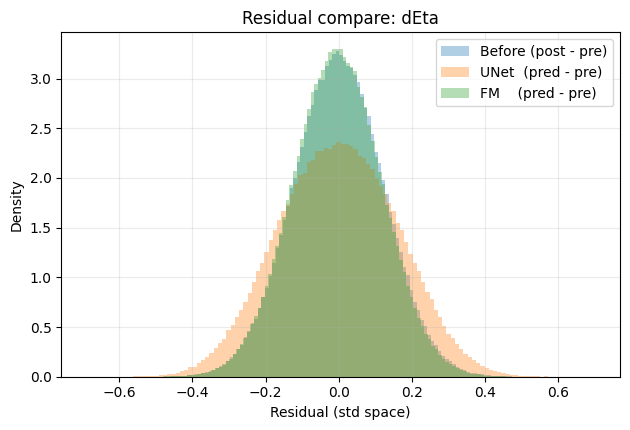

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\resid_compare_dPhi.png


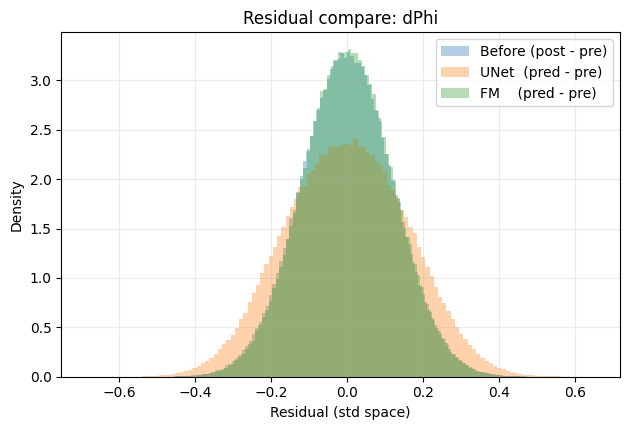

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\resid_compare_log_pt.png


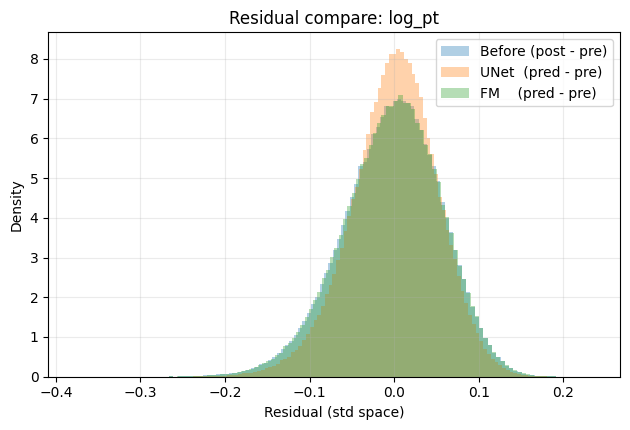

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\resid_compare_log_E.png


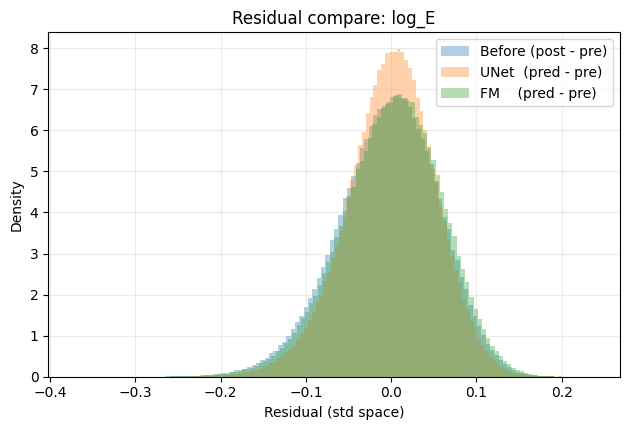

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\resid_compare_log_pt_rel.png


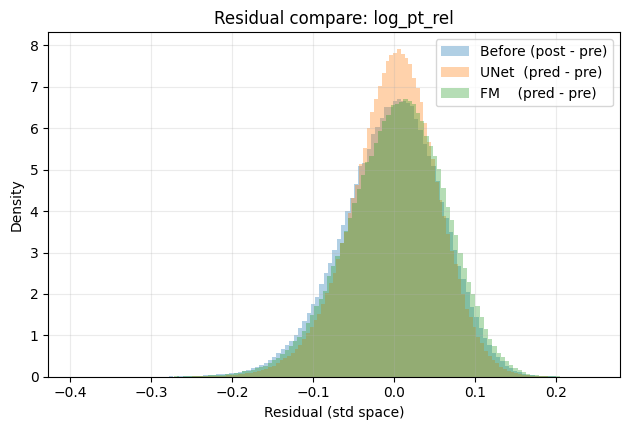

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\resid_compare_log_E_rel.png


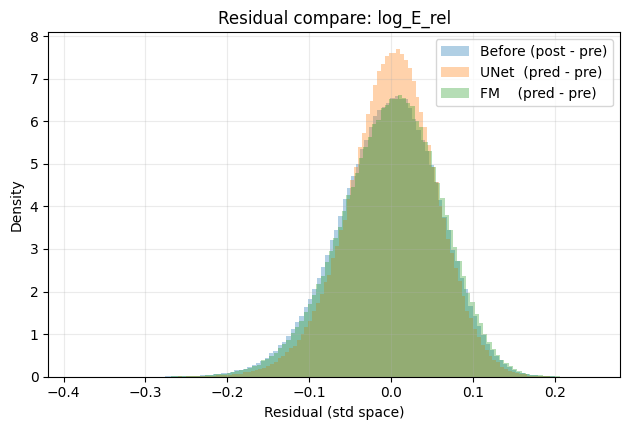

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\resid_compare_dR.png


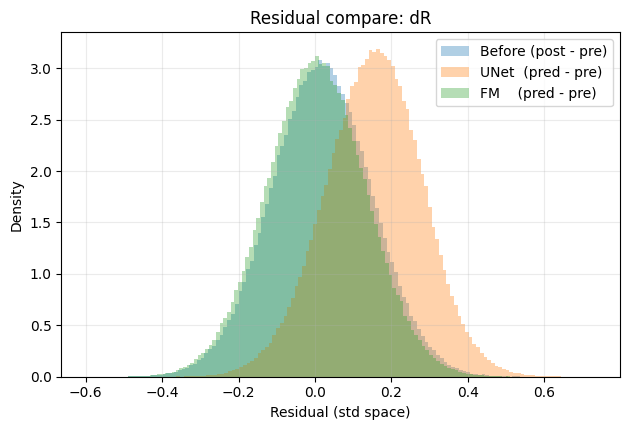

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\scatter_compare_dEta.png


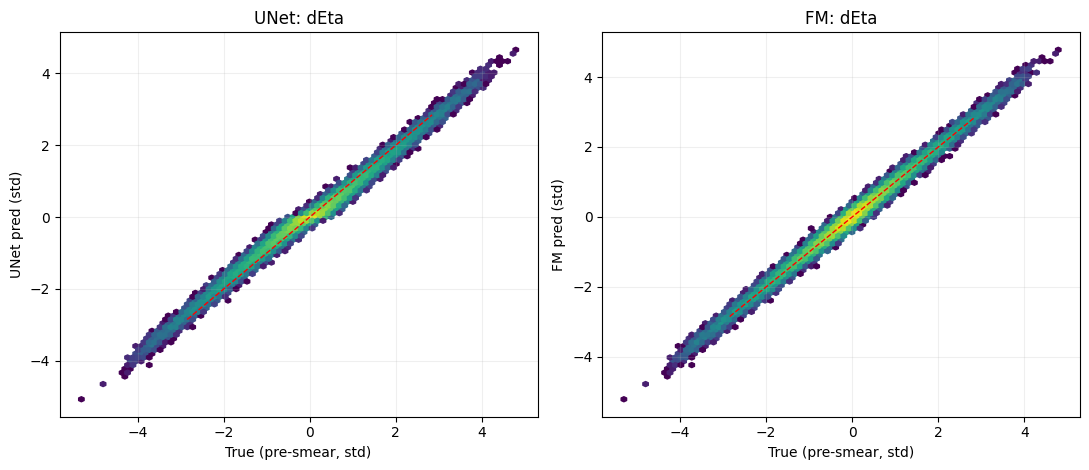

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\scatter_compare_dPhi.png


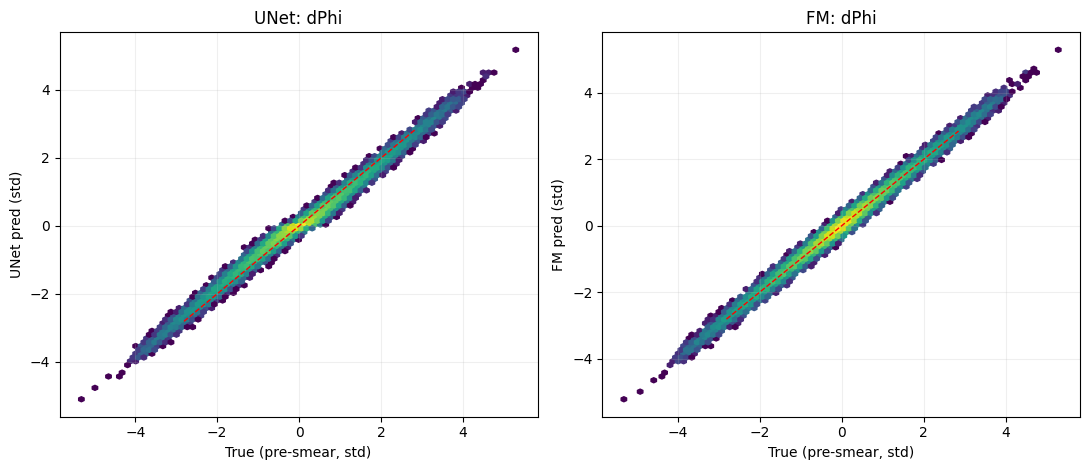

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\scatter_compare_log_pt.png


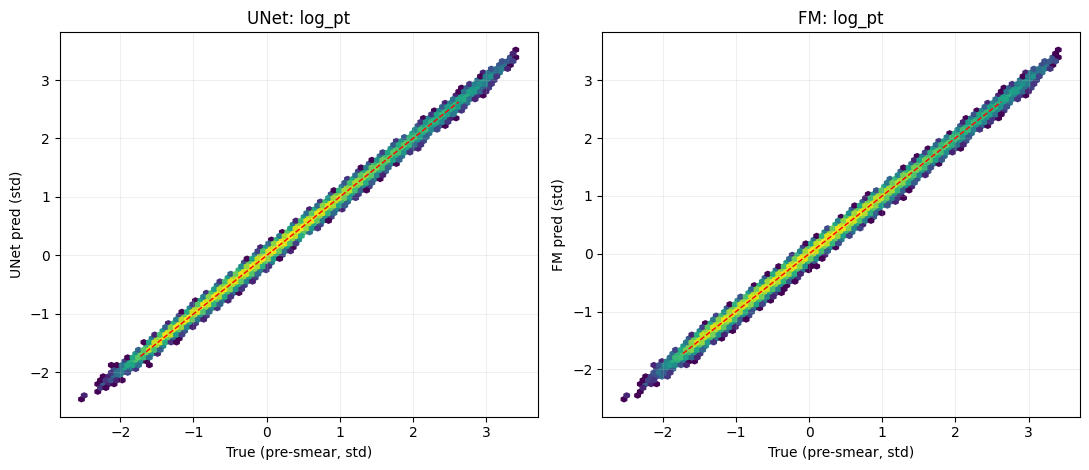

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\scatter_compare_log_E.png


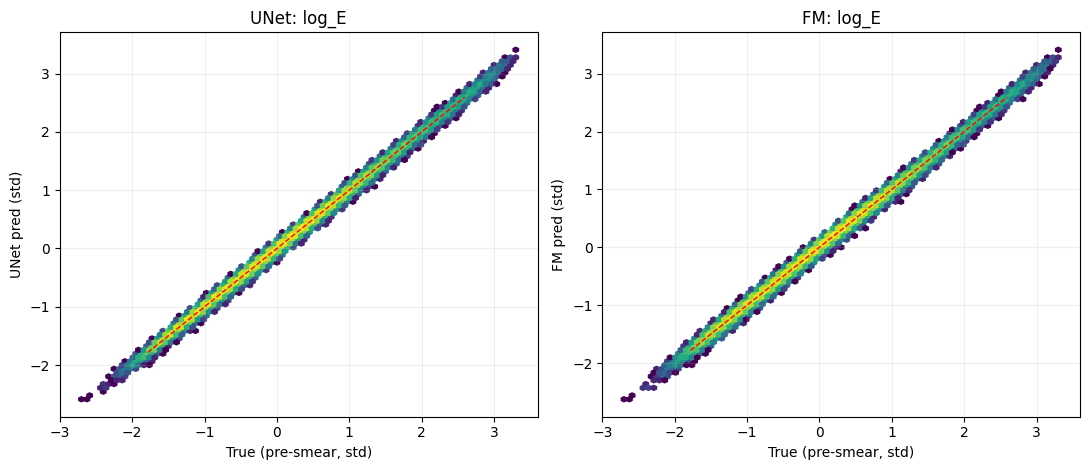

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\scatter_compare_log_pt_rel.png


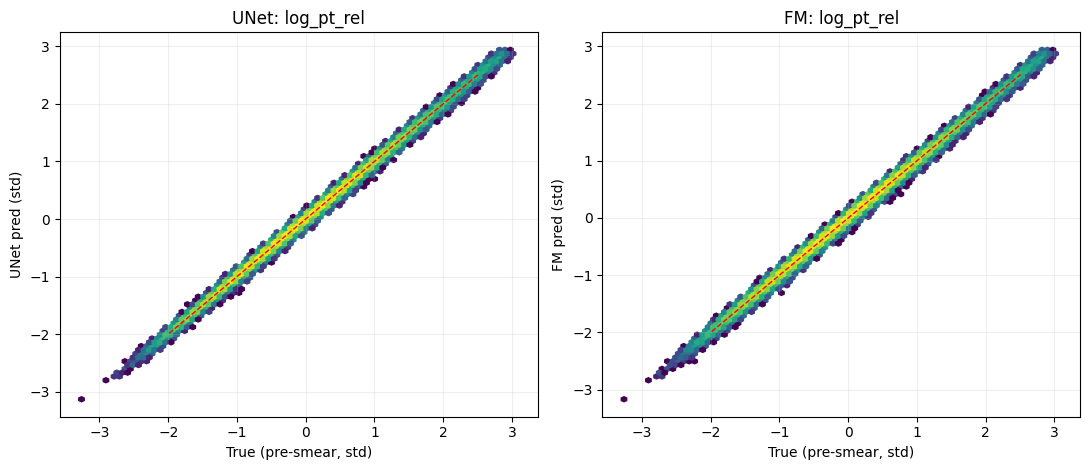

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\scatter_compare_log_E_rel.png


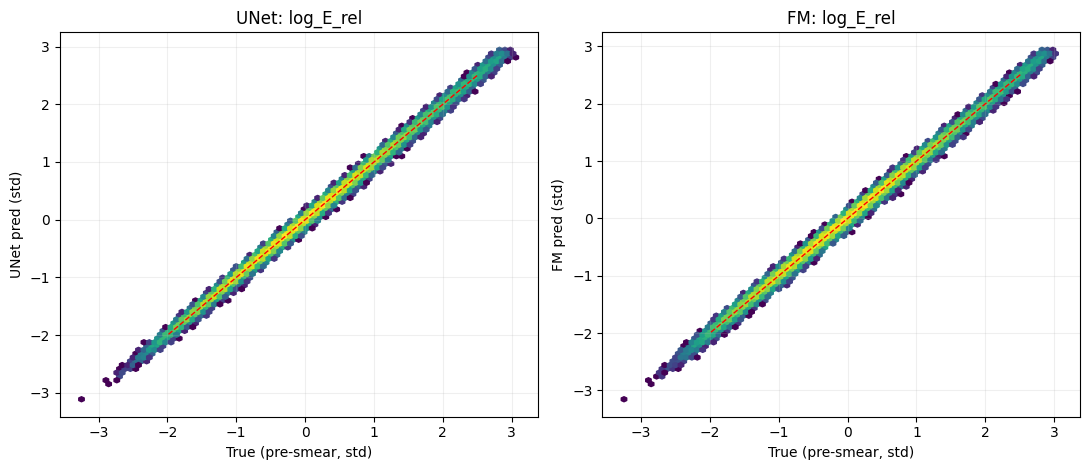

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\scatter_compare_dR.png


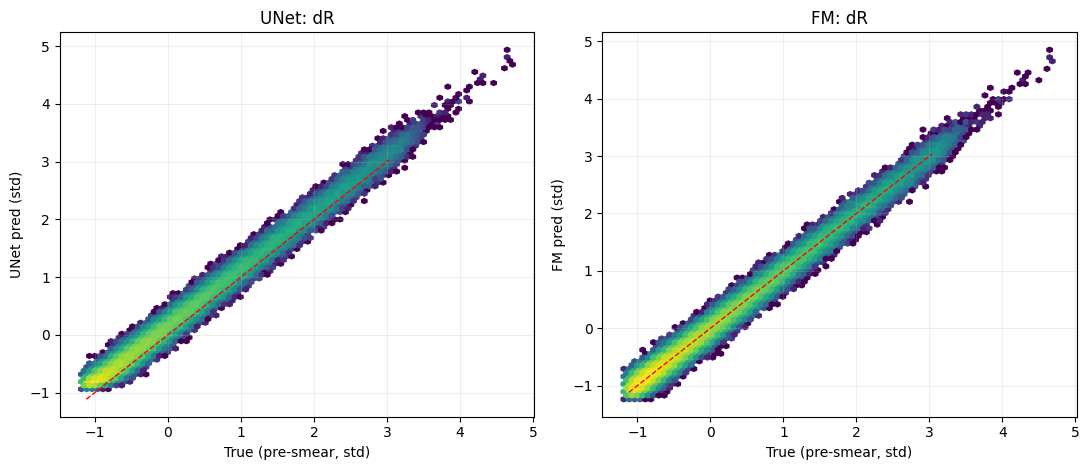

MAE(dR std) before/unet/fm (singleton): 0.10654841363430023 0.16443002223968506 0.10535896569490433
MAE(dR std) before/unet/fm (merged)   : 0.10466782003641129 0.17108340561389923 0.10188177227973938

Metrics summary (std space) | split=all | n_tokens=487518
feature	method	bias	mae	rmse	abs_p50	abs_p90	abs_p99
dEta	before	-0.000183	0.098263	0.123182	0.082969	0.202335	0.317790
dEta	unet	-0.000712	0.130065	0.160653	0.112935	0.263089	0.395639
dEta	fm	-0.004182	0.096848	0.121427	0.081788	0.199488	0.313470
dPhi	before	0.000224	0.097033	0.121609	0.081974	0.200031	0.313524
dPhi	unet	-0.000437	0.128706	0.158952	0.111721	0.259959	0.391791
dPhi	fm	0.002544	0.095772	0.120039	0.080864	0.197186	0.310097
log_pt	before	-0.003039	0.046197	0.058315	0.038847	0.094964	0.155257
log_pt	unet	-0.000090	0.040226	0.051228	0.033153	0.083800	0.138923
log_pt	fm	-0.002619	0.046202	0.058299	0.038859	0.094910	0.155000
log_E	before	-0.003587	0.047022	0.059348	0.039512	0.096654	0.157901
log_E	unet	-0.000376	0.041123	0

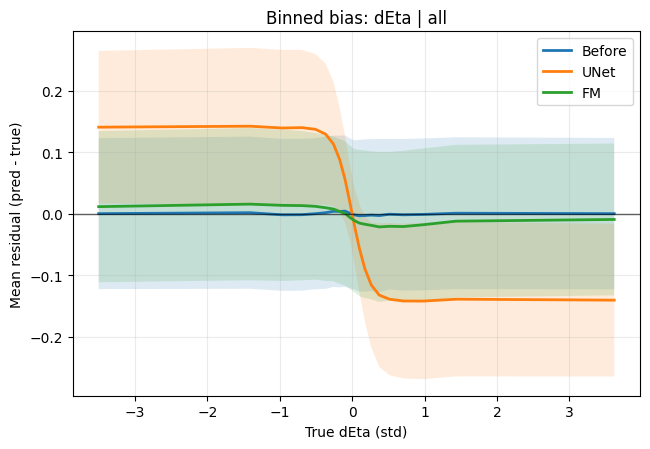

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_dPhi_all.png


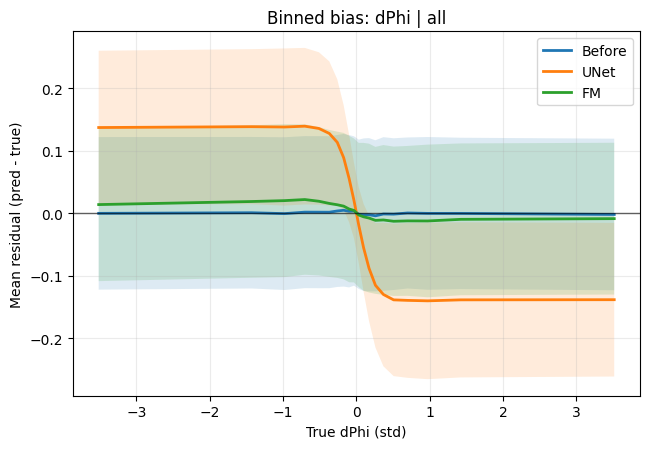

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_pt_all.png


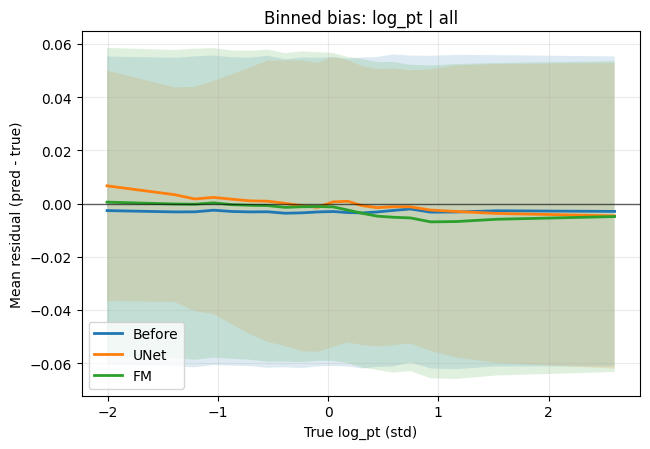

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_E_all.png


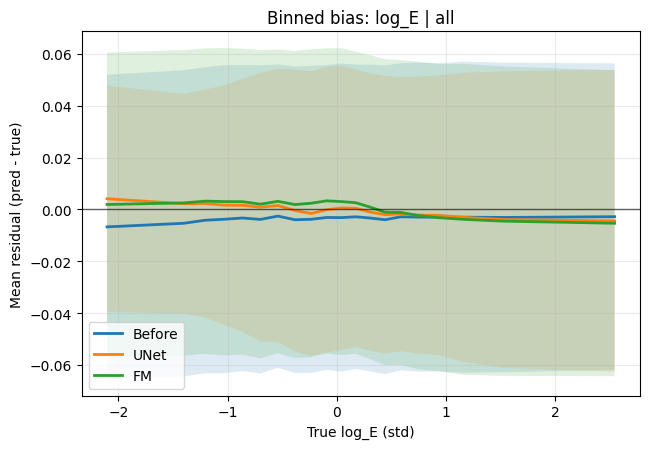

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_pt_rel_all.png


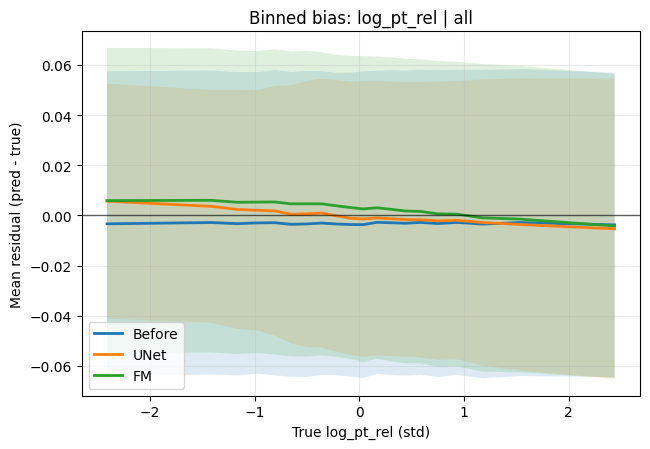

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_E_rel_all.png


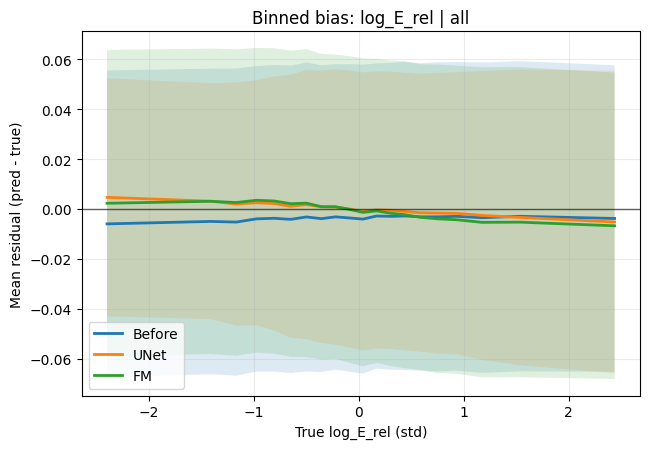

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_dR_all.png


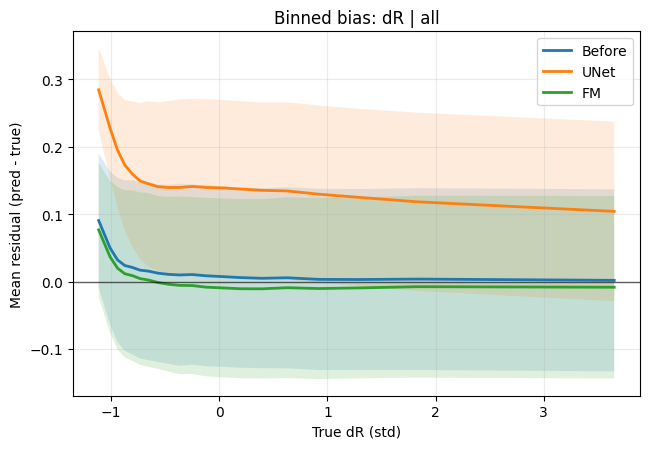

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_dEta_merged.png


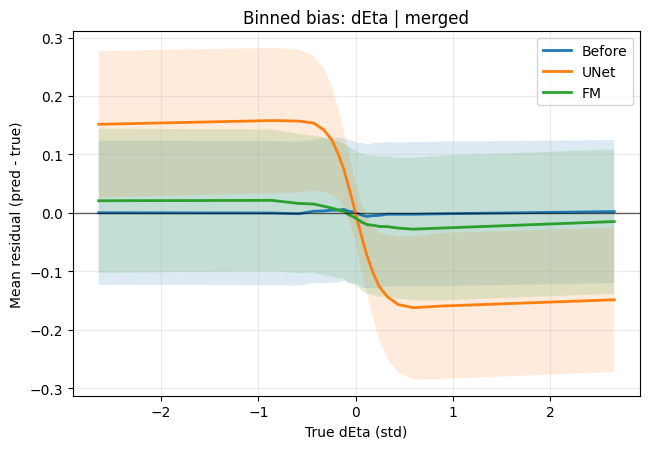

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_dPhi_merged.png


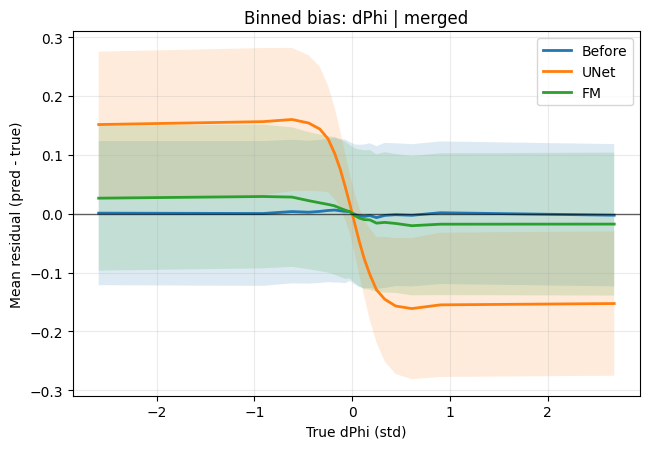

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_pt_merged.png


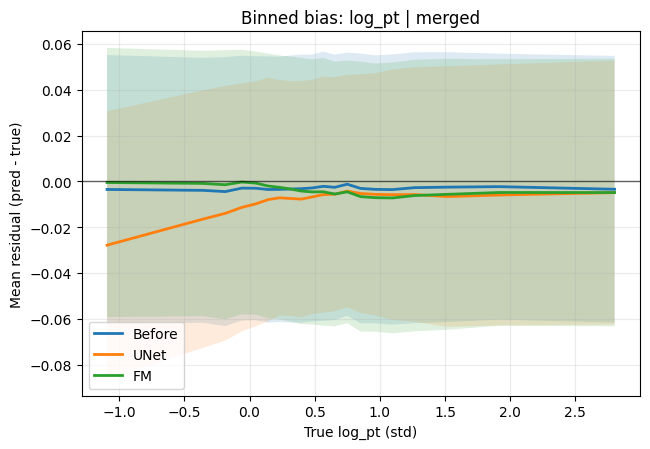

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_E_merged.png


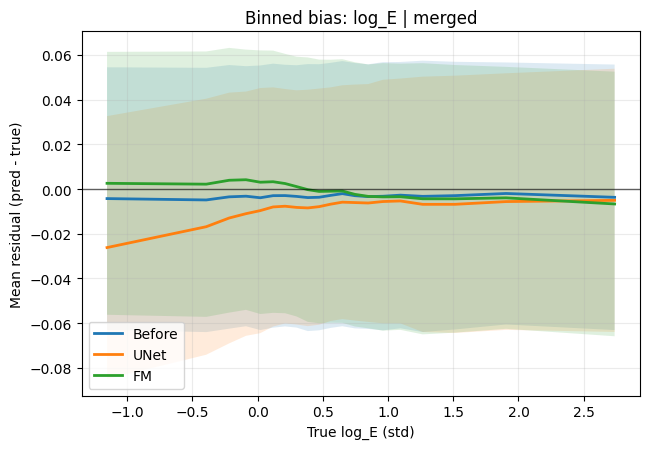

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_pt_rel_merged.png


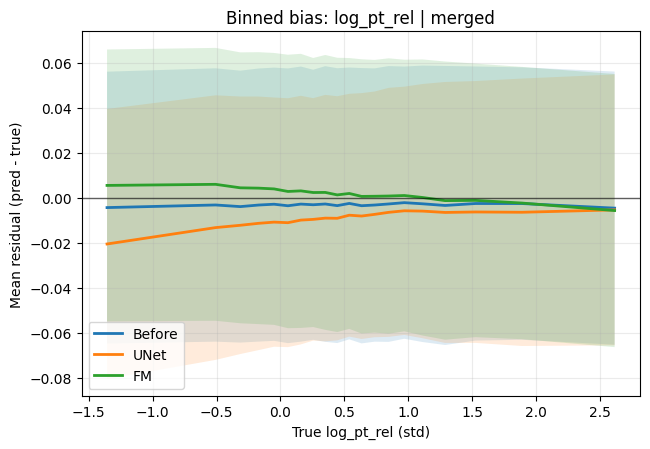

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_log_E_rel_merged.png


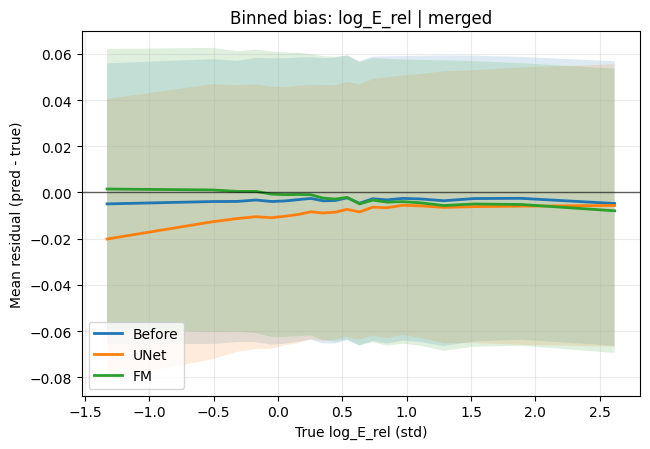

Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\bias_dR_merged.png


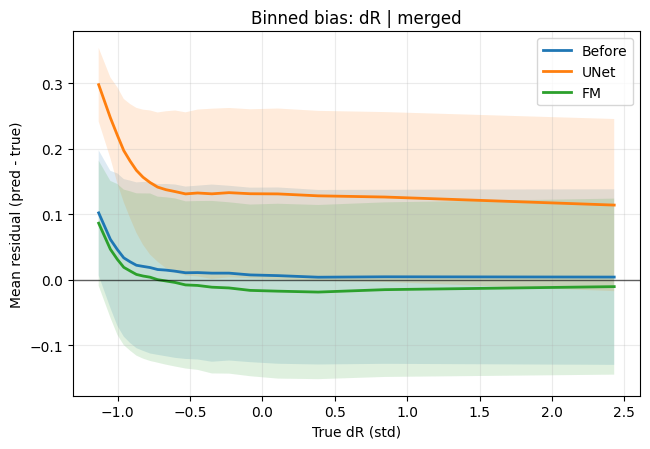

In [7]:
# Visualizations
# 使用 cell0 中根据 feature_kind 自动生成的 feat_names

@torch.no_grad()
def collect_all(loader):
    """Collect x/y/mask (and origin_counts if present) from a loader.

    注意：这里不依赖任何模型，避免出现未定义的全局 model。
    """
    ys = []
    xs = []
    masks = []
    counts = []
    for batch in loader:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        y = batch['y'].to(device)
        ys.append(y.cpu().numpy())
        xs.append(x.cpu().numpy())
        masks.append(m.cpu().numpy())
        if 'origin_counts' in batch:
            counts.append(batch['origin_counts'].cpu().numpy())

    out = {
        'y': np.concatenate(ys, axis=0),
        'x': np.concatenate(xs, axis=0),
        'mask': np.concatenate(masks, axis=0),
    }
    if counts:
        out['origin_counts'] = np.concatenate(counts, axis=0)
    return out

pack = collect_all(test_loader)
y_std = pack['y']
x_std = pack['x']
mask_np = pack['mask']
origin_c = pack.get('origin_counts')

# UNet predictions (std space)
with torch.no_grad():
    pred_unet = []
    for batch in test_loader:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        out = unet(x, m)
        mu = out[0] if isinstance(out, tuple) else out
        pred_unet.append(mu.cpu().numpy())
    pred_unet = np.concatenate(pred_unet, axis=0)

# FM predictions via Euler sampling (std space)
fm_steps = int(CONFIG['fm']['sample_steps'])
fm_sampler = str(CONFIG['fm'].get('sampler', 'euler')).lower()
with torch.no_grad():
    pred_fm = []
    for batch in test_loader:
        x0 = batch['x'].to(device)
        m = batch['mask'].to(device)
        if fm_sampler == 'heun':
            pred = tool.fm_sample_heun(fm, x0=x0, cond=x0, mask=m, steps=fm_steps)
        else:
            pred = tool.fm_sample_euler(fm, x0=x0, cond=x0, mask=m, steps=fm_steps)
        pred_fm.append(pred.cpu().numpy())
    pred_fm = np.concatenate(pred_fm, axis=0)

# 1) per-feature residual distributions (before vs UNet vs FM)
for i, name in enumerate(feat_names):
    x_i = x_std[..., i][mask_np]
    y_i = y_std[..., i][mask_np]
    u_i = pred_unet[..., i][mask_np]
    f_i = pred_fm[..., i][mask_np]

    r_before = x_i - y_i
    r_unet = u_i - y_i
    r_fm = f_i - y_i

    # dPhi 在标准化空间下要先映射回角度空间做 wrap，再除回 std
    if name == 'dPhi':
        sc = float(feat_stds[i])
        r_before = tool.wrap_dphi_np(r_before * sc) / sc
        r_unet = tool.wrap_dphi_np(r_unet * sc) / sc
        r_fm = tool.wrap_dphi_np(r_fm * sc) / sc

    plt.figure(figsize=(6.4, 4.4))
    bins = 120
    plt.hist(r_before, bins=bins, density=True, alpha=0.35, label='Before (post - pre)')
    plt.hist(r_unet, bins=bins, density=True, alpha=0.35, label='UNet  (pred - pre)')
    plt.hist(r_fm, bins=bins, density=True, alpha=0.35, label='FM    (pred - pre)')
    plt.title(f'Residual compare: {name}')
    plt.xlabel('Residual (std space)')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f'resid_compare_{name}.png')
    plt.savefig(fig_path, dpi=160, bbox_inches='tight')
    print('Saved figure:', fig_path)
    plt.show()

# 2) pred vs true scatter (UNet & FM)
N_scatter = 100000
sel = np.where(mask_np.reshape(-1))[0]
if sel.size > N_scatter:
    sel = np.random.RandomState(0).choice(sel, size=N_scatter, replace=False)

for i, name in enumerate(feat_names):
    y_flat = y_std[..., i].reshape(-1)[sel]
    u_flat = pred_unet[..., i].reshape(-1)[sel]
    f_flat = pred_fm[..., i].reshape(-1)[sel]

    lo = np.percentile(np.concatenate([y_flat, u_flat, f_flat]), 1)
    hi = np.percentile(np.concatenate([y_flat, u_flat, f_flat]), 99)

    plt.figure(figsize=(11.0, 4.8))
    plt.subplot(1, 2, 1)
    plt.hexbin(y_flat, u_flat, gridsize=80, bins='log', mincnt=1)
    plt.plot([lo, hi], [lo, hi], 'r--', lw=1)
    plt.xlabel('True (pre-smear, std)')
    plt.ylabel('UNet pred (std)')
    plt.title(f'UNet: {name}')
    plt.grid(True, alpha=0.2)

    plt.subplot(1, 2, 2)
    plt.hexbin(y_flat, f_flat, gridsize=80, bins='log', mincnt=1)
    plt.plot([lo, hi], [lo, hi], 'r--', lw=1)
    plt.xlabel('True (pre-smear, std)')
    plt.ylabel('FM pred (std)')
    plt.title(f'FM: {name}')
    plt.grid(True, alpha=0.2)

    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f'scatter_compare_{name}.png')
    plt.savefig(fig_path, dpi=160, bbox_inches='tight')
    print('Saved figure:', fig_path)
    plt.show()

# 3) merged vs singleton token breakdown (quick MAE on dR)
if origin_c is not None:
    m_flat = mask_np.reshape(-1)
    c_flat = origin_c.reshape(-1)
    is_merged = (c_flat > 1) & m_flat
    is_single = (c_flat == 1) & m_flat

    def _mae(a, sel):
        return float(np.mean(np.abs(a[sel]))) if np.any(sel) else float('nan')

    if 'dR' in feat_names:
        i = feat_names.index('dR')
        r_before = (x_std[..., i] - y_std[..., i]).reshape(-1)
        r_unet = (pred_unet[..., i] - y_std[..., i]).reshape(-1)
        r_fm = (pred_fm[..., i] - y_std[..., i]).reshape(-1)
        print('MAE(dR std) before/unet/fm (singleton):', _mae(r_before, is_single), _mae(r_unet, is_single), _mae(r_fm, is_single))
        print('MAE(dR std) before/unet/fm (merged)   :', _mae(r_before, is_merged), _mae(r_unet, is_merged), _mae(r_fm, is_merged))
    else:
        # 当前 feature_kind 不含 dR：用 dEta/dPhi 在 raw 空间派生 dR，再比较（更鲁棒，不会因为配置不同崩溃）
        deta_i = feat_names.index('dEta')
        dphi_i = feat_names.index('dPhi')

        def _raw(arr_std, idx):
            return arr_std[..., idx] * feat_stds[idx] + feat_means[idx]

        dr_true = np.sqrt(_raw(y_std, deta_i) ** 2 + _raw(y_std, dphi_i) ** 2)
        dr_before = np.sqrt(_raw(x_std, deta_i) ** 2 + _raw(x_std, dphi_i) ** 2)
        dr_unet = np.sqrt(_raw(pred_unet, deta_i) ** 2 + _raw(pred_unet, dphi_i) ** 2)
        dr_fm = np.sqrt(_raw(pred_fm, deta_i) ** 2 + _raw(pred_fm, dphi_i) ** 2)

        r_before = (dr_before - dr_true).reshape(-1)
        r_unet = (dr_unet - dr_true).reshape(-1)
        r_fm = (dr_fm - dr_true).reshape(-1)

        print('MAE(dR raw) before/unet/fm (singleton):', _mae(r_before, is_single), _mae(r_unet, is_single), _mae(r_fm, is_single))
        print('MAE(dR raw) before/unet/fm (merged)   :', _mae(r_before, is_merged), _mae(r_unet, is_merged), _mae(r_fm, is_merged))

# 4) Quantitative tables (MAE/RMSE + tail quantiles) and binned bias curves
# 说明：直方图可能看不出系统偏差；这里补充数值表和按 true 分桶的 bias 曲线。

res_before = x_std - y_std
res_unet = pred_unet - y_std
res_fm = pred_fm - y_std

# flatten token-level indices
m_flat = mask_np.reshape(-1)

splits = [('all', m_flat)]
if origin_c is not None:
    c_flat = origin_c.reshape(-1)
    splits = [
        ('all', m_flat),
        ('singleton', (c_flat == 1) & m_flat),
        ('merged', (c_flat > 1) & m_flat),
    ]


def _metrics(res_1d: np.ndarray):
    # res_1d: residual vector
    if res_1d.size == 0:
        return {'bias': np.nan, 'mae': np.nan, 'rmse': np.nan, 'p50': np.nan, 'p90': np.nan, 'p99': np.nan}
    abs_r = np.abs(res_1d)
    return {
        'bias': float(np.mean(res_1d)),
        'mae': float(np.mean(abs_r)),
        'rmse': float(np.sqrt(np.mean(res_1d ** 2))),
        'p50': float(np.quantile(abs_r, 0.50)),
        'p90': float(np.quantile(abs_r, 0.90)),
        'p99': float(np.quantile(abs_r, 0.99)),
    }


def print_metrics_table(split_name: str, sel_flat: np.ndarray):
    print('\n' + '=' * 80)
    print(f"Metrics summary (std space) | split={split_name} | n_tokens={int(sel_flat.sum())}")
    print('=' * 80)
    header = ['feature', 'method', 'bias', 'mae', 'rmse', 'abs_p50', 'abs_p90', 'abs_p99']
    print('\t'.join(header))

    for i, name in enumerate(feat_names):
        y_flat = y_std[..., i].reshape(-1)[sel_flat]
        # 防止空数组
        if y_flat.size == 0:
            continue
        for method, res in [('before', res_before), ('unet', res_unet), ('fm', res_fm)]:
            r = res[..., i].reshape(-1)[sel_flat]
            if name == 'dPhi':
                sc = float(feat_stds[i])
                r = tool.wrap_dphi_np(r * sc) / sc
            m = _metrics(r)
            print('\t'.join([
                name,
                method,
                f"{m['bias']:.6f}",
                f"{m['mae']:.6f}",
                f"{m['rmse']:.6f}",
                f"{m['p50']:.6f}",
                f"{m['p90']:.6f}",
                f"{m['p99']:.6f}",
            ]))


for split_name, sel_flat in splits:
    print_metrics_table(split_name, sel_flat)


def plot_binned_bias(feature_idx: int, feature_name: str, *, sel_flat: np.ndarray, split_name: str, n_bins: int = 20):
    # true 分位数分桶，画 E[pred-true | true bin]
    y_flat = y_std[..., feature_idx].reshape(-1)[sel_flat]
    if y_flat.size < 1000:
        return

    qs = np.linspace(0.0, 1.0, int(n_bins) + 1)
    edges = np.quantile(y_flat, qs)
    # 去掉重复边界（避免全落在同一 bin）
    edges = np.unique(edges)
    if edges.size < 3:
        return

    # bin centers
    centers = 0.5 * (edges[:-1] + edges[1:])

    def _binned_stats(res_arr: np.ndarray):
        r_flat = res_arr[..., feature_idx].reshape(-1)[sel_flat]
        if feature_name == 'dPhi':
            sc = float(feat_stds[int(feature_idx)])
            r_flat = tool.wrap_dphi_np(r_flat * sc) / sc
        means = []
        stds = []
        for lo, hi in zip(edges[:-1], edges[1:]):
            inb = (y_flat >= lo) & (y_flat < hi)
            if not np.any(inb):
                means.append(np.nan)
                stds.append(np.nan)
            else:
                means.append(float(np.mean(r_flat[inb])))
                stds.append(float(np.std(r_flat[inb])))
        return np.asarray(means), np.asarray(stds)

    mb, sb = _binned_stats(res_before)
    mu, su = _binned_stats(res_unet)
    mf, sf = _binned_stats(res_fm)

    plt.figure(figsize=(6.6, 4.6))

    # 画均值 bias + 1σ 阴影（不是标准误差）
    plt.plot(centers, mb, label='Before', lw=2)
    plt.fill_between(centers, mb - sb, mb + sb, alpha=0.15)

    plt.plot(centers, mu, label='UNet', lw=2)
    plt.fill_between(centers, mu - su, mu + su, alpha=0.15)

    plt.plot(centers, mf, label='FM', lw=2)
    plt.fill_between(centers, mf - sf, mf + sf, alpha=0.15)

    plt.axhline(0.0, color='k', lw=1, alpha=0.6)
    plt.xlabel(f'True {feature_name} (std)')
    plt.ylabel('Mean residual (pred - true)')
    plt.title(f'Binned bias: {feature_name} | {split_name}')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()

    out = os.path.join(FIG_DIR, f'bias_{feature_name}_{split_name}.png')
    plt.savefig(out, dpi=160, bbox_inches='tight')
    print('Saved figure:', out)
    plt.show()


# binned bias plots（默认画 all；如果你想更细，也可以打开 singleton/merged）
for split_name, sel_flat in splits:
    # 只画 all + merged（merged 通常更难）
    if split_name not in ('all', 'merged'):
        continue
    for i, name in enumerate(feat_names):
        plot_binned_bias(i, name, sel_flat=sel_flat, split_name=split_name, n_bins=20)


Building UNet-unsmeared features...
UNet-unsmeared feats: (70000, 100, 7) (15000, 100, 7) (15000, 100, 7)
Downstream feature kind: 7d | unsmear kind: 7d
Sanity MAE vs PRE (train, downstream std): HLT= 0.07901526987552643 UNSMEAR= 0.0950726568698883

=== Downstream training ===
Loaded checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\downstream\tagger_teacher_offfull_7d.pt
Loaded checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\downstream\tagger_student1_hlt_7d.pt


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Loaded checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\downstream\tagger_student2_unsmear_7d_uns7d.pt
Loaded checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\downstream\tagger_student3_presmear_7d.pt
Loaded checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\downstream\tagger_student1_hlt_kd_7d.pt
Loaded checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\downstream\tagger_student2_unsmear_kd_7d_uns7d.pt
Loaded checkpoint: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\ckpts\downstream\tagger_student3_presmear_kd_7d.pt

=== Test evaluation ===
Teacher(OFF_FULL) AUC=0.93910
Student1(HLT) AUC=0.90951
Student2(UNSMEAR+HLT) AUC=0.90689
Student3(PRE-SMEAR) AUC=0.93566
Student1(HLT)+KD AUC=0.91810
Student2(UNSMEAR+HLT)+KD AUC=0.91710
Student3(PRE-SMEAR)+KD AUC=0.94113
Saved figure: d:\PracticeTagging\tagging\unsmear\runs\unsmear_test_full1\figs\downstream_roc_logfpr.png


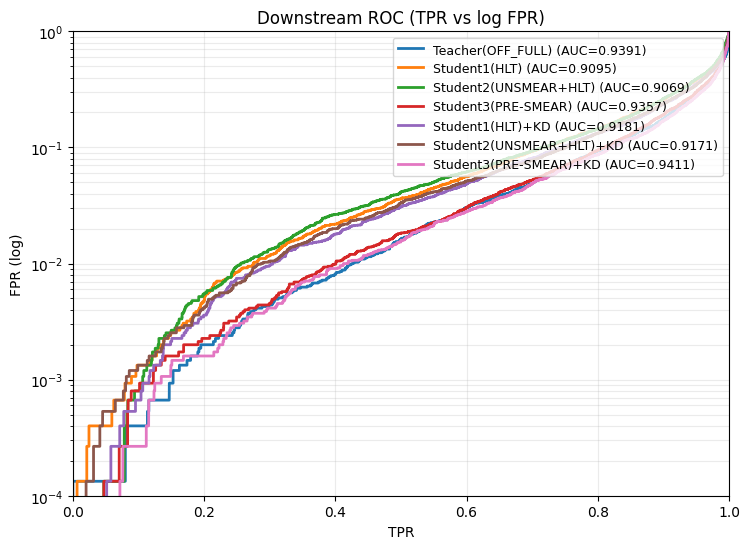

In [9]:
# Downstream tagger evaluation: Teacher(OFF)/Student1(HLT)/Student2(HLT+UNSMEAR)/Student1+KD/Student2+KD
# 说明：这里用 Baseline 的 ParticleTransformerKD 作为统一架构，输出一张 HEP-style ROC（x=TPR, y=log FPR）。

import importlib.util
import sys
import hashlib
from pathlib import Path

from model import ParticleTransformerKD  # noqa: E402


def _load_module(name: str, path: str):
    # 关键：先把 module 放进 sys.modules，再 exec_module。
    # 否则 dataclasses 在装饰 @dataclass 时会找不到所属模块，触发 NoneType.__dict__ 错误。
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Failed to load module spec: {path}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


# 直接复用 notebook 开头已经 import 的 `tool`
baseline_tool = tool

# -----------------------------
# 1) Build unsmeared view (UNet prediction) for train/val/test
# -----------------------------
@torch.no_grad()
def _predict_unet_feats(x_std_np: np.ndarray, mask_np: np.ndarray, *, bs: int = 512) -> np.ndarray:
    unet.eval()
    ds = tool.UnsmearJetDataset(x_std_np, x_std_np, mask_np)  # y 不用
    ld = DataLoader(ds, batch_size=int(bs), shuffle=False)
    outs = []
    for batch in ld:
        x = batch['x'].to(device)
        m = batch['mask'].to(device)
        out = unet(x, m)
        mu = out[0] if isinstance(out, tuple) else out
        mu = mu * m.to(mu.dtype).unsqueeze(-1)
        outs.append(mu.cpu().numpy())
    return np.concatenate(outs, axis=0)


print('Building UNet-unsmeared features...')
uns_train = _predict_unet_feats(x_train[train_idx], post_mask[train_idx], bs=512)
uns_val = _predict_unet_feats(x_train[val_idx], post_mask[val_idx], bs=512)
uns_test = _predict_unet_feats(x_train[test_idx], post_mask[test_idx], bs=512)
print('UNet-unsmeared feats:', uns_train.shape, uns_val.shape, uns_test.shape)

# Full OFF view (teacher): use original offline constituents (NOT pre-smear)
# 说明：teacher 使用完整 offline 信息；HLT/unsmear/presmear 都投影到 offline 标准化空间，保证可比。

pt_thr_off = float(CONFIG['hlt_effects'].get('pt_threshold_offline', 0.5))
off_mask_full = mask_raw & (constituents_raw[:, :, 0] >= pt_thr_off)
off_const_full = constituents_raw.copy()
off_const_full[~off_mask_full] = 0.0

DOWN_KIND = str(CONFIG.get('downstream_feature_kind', '7d')).lower()

axis_off = tool.compute_jet_axis(off_const_full, off_mask_full)
feat_off_full = tool.compute_features_with_axis(off_const_full, off_mask_full, axis_off, kind=DOWN_KIND)

# offline standardization stats (teacher space)
off_means, off_stds = tool.get_stats(feat_off_full, off_mask_full, train_idx)

feat_off_full_std = tool.standardize(feat_off_full, off_mask_full, off_means, off_stds, clip=10.0)

# 下游输入（HLT / pre-smear）统一用 DOWN_KIND 计算
feat_post_down = tool.compute_features_with_axis(post_const, post_mask, axis_post, kind=DOWN_KIND)
feat_pre_down = tool.compute_features_with_axis(pre_const, post_mask, axis_post, kind=DOWN_KIND)

feat_hlt_std = tool.standardize(feat_post_down, post_mask, off_means, off_stds, clip=10.0)
feat_pre_std = tool.standardize(feat_pre_down, post_mask, off_means, off_stds, clip=10.0)  # pre-smear raw view

# UNet unsmear predictions are in UNSMEAR std-space; convert -> raw feature space -> (optional) upgrade -> offline std-space
uns_train_raw = uns_train * feat_stds[None, None, :] + feat_means[None, None, :]
uns_val_raw = uns_val * feat_stds[None, None, :] + feat_means[None, None, :]
uns_test_raw = uns_test * feat_stds[None, None, :] + feat_means[None, None, :]

# 如果 unsmear 不是 7d，但下游希望 7d，则补全到 7d（使用 post-smear axis）
if DOWN_KIND == '7d' and str(CONFIG['feature_kind']).lower() != '7d':
    axis_post_train = {k: v[train_idx] for k, v in axis_post.items()}
    axis_post_val = {k: v[val_idx] for k, v in axis_post.items()}
    axis_post_test = {k: v[test_idx] for k, v in axis_post.items()}

    # 只替换 unsmear 真正预测到的维度，其余维度沿用 HLT（避免 3d->7d 用近似 E 反而劣化）
    base_names = tool.get_feat_names(CONFIG['feature_kind'])
    names7 = tool.get_feat_names('7d')
    idx7 = {n: i for i, n in enumerate(names7)}

    def _hybrid_upgrade(uns_raw: np.ndarray, post_raw7: np.ndarray, axis_split: dict, mask_split: np.ndarray) -> np.ndarray:
        out = post_raw7.copy().astype(np.float32)
        for j, n in enumerate(base_names):
            out[..., int(idx7[n])] = uns_raw[..., j].astype(np.float32)

        dEta = out[..., int(idx7['dEta'])]
        dPhi = out[..., int(idx7['dPhi'])]
        log_pt = out[..., int(idx7['log_pt'])]
        log_E = out[..., int(idx7['log_E'])]

        pt = np.exp(np.clip(log_pt, -20.0, 20.0)).astype(np.float32)
        E = np.exp(np.clip(log_E, -20.0, 20.0)).astype(np.float32)

        # 用 unsmear 后的 token 重新聚合 jet_pt/jet_E（而不是沿用 post 的 jet_pt/jet_E）
        # 注意：这里仍然使用 post 的 jet_eta/jet_phi 来定义 frame（与训练/推理一致，避免引入额外坐标系变化）
        jet_eta = np.asarray(axis_split['jet_eta'], dtype=np.float32)  # [N,1]
        jet_phi = np.asarray(axis_split['jet_phi'], dtype=np.float32)  # [N,1]
        eta_abs = dEta + jet_eta
        phi_abs = tool.wrap_dphi_np(dPhi + jet_phi)

        m = mask_split.astype(np.float32)
        px = pt * np.cos(phi_abs) * m
        py = pt * np.sin(phi_abs) * m

        jet_px = np.sum(px, axis=1, keepdims=True).astype(np.float32)
        jet_py = np.sum(py, axis=1, keepdims=True).astype(np.float32)
        jet_pt = np.sqrt(np.maximum(jet_px**2 + jet_py**2, 1e-12)).astype(np.float32)
        jet_E = np.sum(E * m, axis=1, keepdims=True).astype(np.float32)

        out[..., int(idx7['log_pt_rel'])] = np.log(pt / (jet_pt + 1e-8) + 1e-8)
        out[..., int(idx7['log_E_rel'])] = np.log(E / (jet_E + 1e-8) + 1e-8)
        out[..., int(idx7['dR'])] = np.sqrt(dEta**2 + dPhi**2)

        out = np.clip(np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0), -20.0, 20.0).astype(np.float32)
        out[~mask_split] = 0.0
        return out

    post_train_raw7 = feat_post_down[train_idx].astype(np.float32)
    post_val_raw7 = feat_post_down[val_idx].astype(np.float32)
    post_test_raw7 = feat_post_down[test_idx].astype(np.float32)

    uns_train_raw = _hybrid_upgrade(uns_train_raw, post_train_raw7, axis_post_train, post_mask[train_idx])
    uns_val_raw = _hybrid_upgrade(uns_val_raw, post_val_raw7, axis_post_val, post_mask[val_idx])
    uns_test_raw = _hybrid_upgrade(uns_test_raw, post_test_raw7, axis_post_test, post_mask[test_idx])

uns_train_std = tool.standardize(uns_train_raw, post_mask[train_idx], off_means, off_stds, clip=10.0)
uns_val_std = tool.standardize(uns_val_raw, post_mask[val_idx], off_means, off_stds, clip=10.0)
uns_test_std = tool.standardize(uns_test_raw, post_mask[test_idx], off_means, off_stds, clip=10.0)

print('Downstream feature kind:', DOWN_KIND, '| unsmear kind:', CONFIG['feature_kind'])

# sanity check: unsmear 是否在 downstream space 更接近 pre-smear（token-level, std space）
try:
    m_tr = post_mask[train_idx]
    mae_hlt = float(np.mean(np.abs((feat_hlt_std[train_idx] - feat_pre_std[train_idx])[m_tr])))
    mae_uns = float(np.mean(np.abs((uns_train_std - feat_pre_std[train_idx])[m_tr])))
    print('Sanity MAE vs PRE (train, downstream std): HLT=', mae_hlt, 'UNSMEAR=', mae_uns)
except Exception as e:
    print('Sanity MAE vs PRE skipped:', repr(e))

# split tensors
m_hlt_train, m_hlt_val, m_hlt_test = post_mask[train_idx], post_mask[val_idx], post_mask[test_idx]
m_off_train, m_off_val, m_off_test = off_mask_full[train_idx], off_mask_full[val_idx], off_mask_full[test_idx]

y_tr, y_va, y_te = labels[train_idx], labels[val_idx], labels[test_idx]
w_tr, w_va, w_te = weights[train_idx], weights[val_idx], weights[test_idx]

# For KD, JetDataset expects both off & hlt in same dataset
train_ds_hlt = baseline_tool.JetDataset(feat_off_full_std[train_idx], feat_hlt_std[train_idx], y_tr, m_off_train, m_hlt_train, w_tr)
val_ds_hlt = baseline_tool.JetDataset(feat_off_full_std[val_idx], feat_hlt_std[val_idx], y_va, m_off_val, m_hlt_val, w_va)
test_ds_hlt = baseline_tool.JetDataset(feat_off_full_std[test_idx], feat_hlt_std[test_idx], y_te, m_off_test, m_hlt_test, w_te)

train_ds_uns = baseline_tool.JetDataset(feat_off_full_std[train_idx], uns_train_std, y_tr, m_off_train, m_hlt_train, w_tr)
val_ds_uns = baseline_tool.JetDataset(feat_off_full_std[val_idx], uns_val_std, y_va, m_off_val, m_hlt_val, w_va)
test_ds_uns = baseline_tool.JetDataset(feat_off_full_std[test_idx], uns_test_std, y_te, m_off_test, m_hlt_test, w_te)

# Pre-smear (merge-after, smear-before) raw view + KD (requested)
train_ds_pre = baseline_tool.JetDataset(feat_off_full_std[train_idx], feat_pre_std[train_idx], y_tr, m_off_train, m_hlt_train, w_tr)
val_ds_pre = baseline_tool.JetDataset(feat_off_full_std[val_idx], feat_pre_std[val_idx], y_va, m_off_val, m_hlt_val, w_va)
test_ds_pre = baseline_tool.JetDataset(feat_off_full_std[test_idx], feat_pre_std[test_idx], y_te, m_off_test, m_hlt_test, w_te)

BS_TAG = 256
train_loader_hlt = DataLoader(train_ds_hlt, batch_size=BS_TAG, shuffle=True, drop_last=True)
val_loader_hlt = DataLoader(val_ds_hlt, batch_size=BS_TAG, shuffle=False)
test_loader_hlt = DataLoader(test_ds_hlt, batch_size=BS_TAG, shuffle=False)

train_loader_uns = DataLoader(train_ds_uns, batch_size=BS_TAG, shuffle=True, drop_last=True)
val_loader_uns = DataLoader(val_ds_uns, batch_size=BS_TAG, shuffle=False)
test_loader_uns = DataLoader(test_ds_uns, batch_size=BS_TAG, shuffle=False)

train_loader_pre = DataLoader(train_ds_pre, batch_size=BS_TAG, shuffle=True, drop_last=True)
val_loader_pre = DataLoader(val_ds_pre, batch_size=BS_TAG, shuffle=False)
test_loader_pre = DataLoader(test_ds_pre, batch_size=BS_TAG, shuffle=False)

# -----------------------------
# 2) Train/eval helpers (early stopping on val AUC)
# -----------------------------
TAGGER_CFG = {
    'input_dim': len(tool.get_feat_names(DOWN_KIND)),
    'embed_dim': 128,
    'num_heads': 8,
    'num_layers': 6,
    'ff_dim': 512,
    'dropout': 0.1,
}

TRAIN_TAG = {
    'epochs': 30,
    'lr': 5e-4,
    'weight_decay': 1e-5,
    'warmup_epochs': 3,
    'patience': 6,
    'grad_clip': 1.0,
}

KD_CFG = {
    'kd': {
        'temperature': 2.0,
        'alpha_kd': 0.7,
        'alpha_attn': 0.0,
    }
}


def _make_opt(model):
    opt = torch.optim.AdamW(model.parameters(), lr=float(TRAIN_TAG['lr']), weight_decay=float(TRAIN_TAG['weight_decay']))
    sch = baseline_tool.get_scheduler(opt, int(TRAIN_TAG['warmup_epochs']), int(TRAIN_TAG['epochs']))
    return opt, sch


def _train_standard(name: str, model, train_loader, val_loader, *, feat_key: str, mask_key: str):
    opt, sch = _make_opt(model)
    best_auc, best_state, no_imp = 0.0, None, 0
    for ep in range(1, int(TRAIN_TAG['epochs']) + 1):
        loss, _ = baseline_tool.train_standard(model, train_loader, opt, device, feat_key, mask_key)
        sch.step()
        val_auc, _, _ = baseline_tool.evaluate(model, val_loader, device, feat_key, mask_key)
        if val_auc > best_auc + 1e-4:
            best_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep % 2 == 0 or ep == 1:
            print(f"[{name}] ep={ep:03d} train_loss={loss:.5f} val_auc={val_auc:.5f} best={best_auc:.5f} no_imp={no_imp}")
        if no_imp >= int(TRAIN_TAG['patience']):
            print(f"[{name}] Early stopping")
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def _train_kd(name: str, student, teacher, train_loader, val_loader):
    opt, sch = _make_opt(student)
    best_auc, best_state, no_imp = 0.0, None, 0
    for ep in range(1, int(TRAIN_TAG['epochs']) + 1):
        loss, _ = baseline_tool.train_kd(student, teacher, train_loader, opt, device, KD_CFG)
        sch.step()
        val_auc, _, _ = baseline_tool.evaluate(student, val_loader, device, 'hlt', 'mask_hlt')
        if val_auc > best_auc + 1e-4:
            best_auc = float(val_auc)
            best_state = {k: v.detach().cpu().clone() for k, v in student.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if ep % 2 == 0 or ep == 1:
            print(f"[{name}] ep={ep:03d} train_loss={loss:.5f} val_auc={val_auc:.5f} best={best_auc:.5f} no_imp={no_imp}")
        if no_imp >= int(TRAIN_TAG['patience']):
            print(f"[{name}] Early stopping")
            break
    if best_state is not None:
        student.load_state_dict(best_state)
    return student


# -----------------------------
# 3) Train / load models (with checkpoints)
# -----------------------------
print('\n=== Downstream training ===')

TAG_CKPT_DIR = os.path.join(CKPT_DIR, 'downstream')
tool.ensure_dir(TAG_CKPT_DIR)

# 保存 meta，避免不同配置误加载
_SPLIT_DIGEST = hashlib.sha1(np.asarray(train_idx, dtype=np.int64).tobytes()).hexdigest()[:12]
_META = {
    'run_name': str(RUN_NAME),
    'downstream_feature_kind': str(DOWN_KIND),
    'unsmear_feature_kind': str(CONFIG.get('feature_kind')),
    'tagger_cfg': dict(TAGGER_CFG),
    'split_digest': str(_SPLIT_DIGEST),
}


def _try_load(model, ckpt_path: str) -> bool:
    if not os.path.isfile(ckpt_path):
        return False
    obj = torch.load(ckpt_path, map_location='cpu')

    # meta 校验：如果 split / feature kind / tagger_cfg 不一致，就不要复用 ckpt
    if isinstance(obj, dict) and 'meta' in obj:
        meta = obj.get('meta') or {}
        for k in ['downstream_feature_kind', 'tagger_cfg', 'split_digest']:
            if str(meta.get(k)) != str(_META.get(k)):
                print('Skip checkpoint (meta mismatch):', ckpt_path)
                print('  want', k, '=', _META.get(k))
                print('  got ', k, '=', meta.get(k))
                return False

    state = obj['state_dict'] if isinstance(obj, dict) and 'state_dict' in obj else obj
    model.load_state_dict(state)
    print('Loaded checkpoint:', ckpt_path)
    return True


def _save(model, ckpt_path: str, *, extra: dict | None = None):
    payload = {
        'state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
        'meta': dict(_META),
    }
    if extra is not None:
        payload['extra'] = dict(extra)
    torch.save(payload, ckpt_path)
    print('Saved checkpoint:', ckpt_path)


# Teacher (OFF_FULL)
teacher = ParticleTransformerKD(**TAGGER_CFG).to(device)
_teacher_ckpt = os.path.join(TAG_CKPT_DIR, f"tagger_teacher_offfull_{DOWN_KIND}.pt")
if not _try_load(teacher, _teacher_ckpt):
    teacher = _train_standard('Teacher(OFF)', teacher, train_loader_hlt, val_loader_hlt, feat_key='off', mask_key='mask_off')
    _save(teacher, _teacher_ckpt)

# Student1: HLT
student1 = ParticleTransformerKD(**TAGGER_CFG).to(device)
_s1_ckpt = os.path.join(TAG_CKPT_DIR, f"tagger_student1_hlt_{DOWN_KIND}.pt")
if not _try_load(student1, _s1_ckpt):
    student1 = _train_standard('Student1(HLT)', student1, train_loader_hlt, val_loader_hlt, feat_key='hlt', mask_key='mask_hlt')
    _save(student1, _s1_ckpt)

# Student2: UNSMEAR(+HLT)
student2 = ParticleTransformerKD(**TAGGER_CFG).to(device)
_s2_ckpt = os.path.join(TAG_CKPT_DIR, f"tagger_student2_unsmear_{DOWN_KIND}_uns{str(CONFIG.get('feature_kind')).lower()}.pt")
if not _try_load(student2, _s2_ckpt):
    student2 = _train_standard('Student2(UNSMEAR+HLT)', student2, train_loader_uns, val_loader_uns, feat_key='hlt', mask_key='mask_hlt')
    _save(student2, _s2_ckpt)

# Student3: PRE-SMEAR
student3_pre = ParticleTransformerKD(**TAGGER_CFG).to(device)
_s3_ckpt = os.path.join(TAG_CKPT_DIR, f"tagger_student3_presmear_{DOWN_KIND}.pt")
if not _try_load(student3_pre, _s3_ckpt):
    student3_pre = _train_standard('Student3(PRE-SMEAR)', student3_pre, train_loader_pre, val_loader_pre, feat_key='hlt', mask_key='mask_hlt')
    _save(student3_pre, _s3_ckpt)

# KD students
student1_kd = ParticleTransformerKD(**TAGGER_CFG).to(device)
_s1kd_ckpt = os.path.join(TAG_CKPT_DIR, f"tagger_student1_hlt_kd_{DOWN_KIND}.pt")
if not _try_load(student1_kd, _s1kd_ckpt):
    student1_kd = _train_kd('Student1(HLT)+KD', student1_kd, teacher, train_loader_hlt, val_loader_hlt)
    _save(student1_kd, _s1kd_ckpt)

student2_kd = ParticleTransformerKD(**TAGGER_CFG).to(device)
_s2kd_ckpt = os.path.join(TAG_CKPT_DIR, f"tagger_student2_unsmear_kd_{DOWN_KIND}_uns{str(CONFIG.get('feature_kind')).lower()}.pt")
if not _try_load(student2_kd, _s2kd_ckpt):
    student2_kd = _train_kd('Student2(UNSMEAR+HLT)+KD', student2_kd, teacher, train_loader_uns, val_loader_uns)
    _save(student2_kd, _s2kd_ckpt)

# Pre-smear + KD
student_pre_kd = ParticleTransformerKD(**TAGGER_CFG).to(device)
_prekd_ckpt = os.path.join(TAG_CKPT_DIR, f"tagger_student3_presmear_kd_{DOWN_KIND}.pt")
if not _try_load(student_pre_kd, _prekd_ckpt):
    student_pre_kd = _train_kd('Student3(PRE-SMEAR)+KD', student_pre_kd, teacher, train_loader_pre, val_loader_pre)
    _save(student_pre_kd, _prekd_ckpt)

# -----------------------------
# 4) Evaluate + ROC
# -----------------------------
print('\n=== Test evaluation ===')

auc_t, p_t, y_t = baseline_tool.evaluate(teacher, test_loader_hlt, device, 'off', 'mask_off')
auc_s1, p_s1, _ = baseline_tool.evaluate(student1, test_loader_hlt, device, 'hlt', 'mask_hlt')
auc_s2, p_s2, _ = baseline_tool.evaluate(student2, test_loader_uns, device, 'hlt', 'mask_hlt')
auc_s3pre, p_s3pre, _ = baseline_tool.evaluate(student3_pre, test_loader_pre, device, 'hlt', 'mask_hlt')
auc_s1kd, p_s1kd, _ = baseline_tool.evaluate(student1_kd, test_loader_hlt, device, 'hlt', 'mask_hlt')
auc_s2kd, p_s2kd, _ = baseline_tool.evaluate(student2_kd, test_loader_uns, device, 'hlt', 'mask_hlt')
auc_prekd, p_prekd, _ = baseline_tool.evaluate(student_pre_kd, test_loader_pre, device, 'hlt', 'mask_hlt')

print(f"Teacher(OFF_FULL) AUC={auc_t:.5f}")
print(f"Student1(HLT) AUC={auc_s1:.5f}")
print(f"Student2(UNSMEAR+HLT) AUC={auc_s2:.5f}")
print(f"Student3(PRE-SMEAR) AUC={auc_s3pre:.5f}")
print(f"Student1(HLT)+KD AUC={auc_s1kd:.5f}")
print(f"Student2(UNSMEAR+HLT)+KD AUC={auc_s2kd:.5f}")
print(f"Student3(PRE-SMEAR)+KD AUC={auc_prekd:.5f}")

curves = {
    'Teacher(OFF_FULL)': (p_t, y_t, auc_t),
    'Student1(HLT)': (p_s1, y_t, auc_s1),
    'Student2(UNSMEAR+HLT)': (p_s2, y_t, auc_s2),
    'Student3(PRE-SMEAR)': (p_s3pre, y_t, auc_s3pre),
    'Student1(HLT)+KD': (p_s1kd, y_t, auc_s1kd),
    'Student2(UNSMEAR+HLT)+KD': (p_s2kd, y_t, auc_s2kd),
    'Student3(PRE-SMEAR)+KD': (p_prekd, y_t, auc_prekd),
}

plt.figure(figsize=(7.6, 5.6))
for name, (p, y, aucv) in curves.items():
    fpr, tpr, _auc = baseline_tool.compute_roc(y, p)
    plt.semilogy(tpr, np.clip(fpr, 1e-6, 1.0), lw=2, label=f"{name} (AUC={aucv:.4f})")

plt.xlabel('TPR')
plt.ylabel('FPR (log)')
plt.title('Downstream ROC (TPR vs log FPR)')
plt.grid(True, which='both', alpha=0.25)
plt.legend(loc='upper right', fontsize=9)
plt.xlim(0.0, 1.0)
plt.ylim(1e-4, 1.0)

out = os.path.join(FIG_DIR, 'downstream_roc_logfpr.png')
plt.tight_layout()
plt.savefig(out, dpi=170, bbox_inches='tight')
print('Saved figure:', out)
plt.show()
